# Frank-Wolfe Geometry: Target Outside Feasible Sets

Frank-Wolfe iterates
$$
s_k=\arg\min_{s\in\mathcal{D}}\langle \nabla f(x_k), s\rangle,\quad
x_{k+1} = (1-\gamma_k)x_k+\gamma_k s_k.
$$
We set the target outside both a square and a pentagon and display trajectories in black.


## Square and pentagon experiments


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

OUT = Path("python/frank-wolfe"); OUT.mkdir(parents=True, exist_ok=True)

def fw(vertices, target, n_iter=55):
    x = vertices.mean(axis=0)
    traj = [x.copy()]
    for k in range(1, n_iter+1):
        g = x - target
        j = np.argmin(vertices @ g)
        s = vertices[j]
        gamma = 2.0 / (k + 2)
        x = (1-gamma)*x + gamma*s
        traj.append(x.copy())
    return np.array(traj)

sq = np.array([[-1,-1],[1,-1],[1,1],[-1,1]])
ang = np.linspace(0, 2*np.pi, 5, endpoint=False) + 0.35
pent = np.c_[np.cos(ang), np.sin(ang)]
target = np.array([2.1, 1.8])  # outside both sets
traj_sq = fw(sq, target)
traj_pt = fw(pent, target)


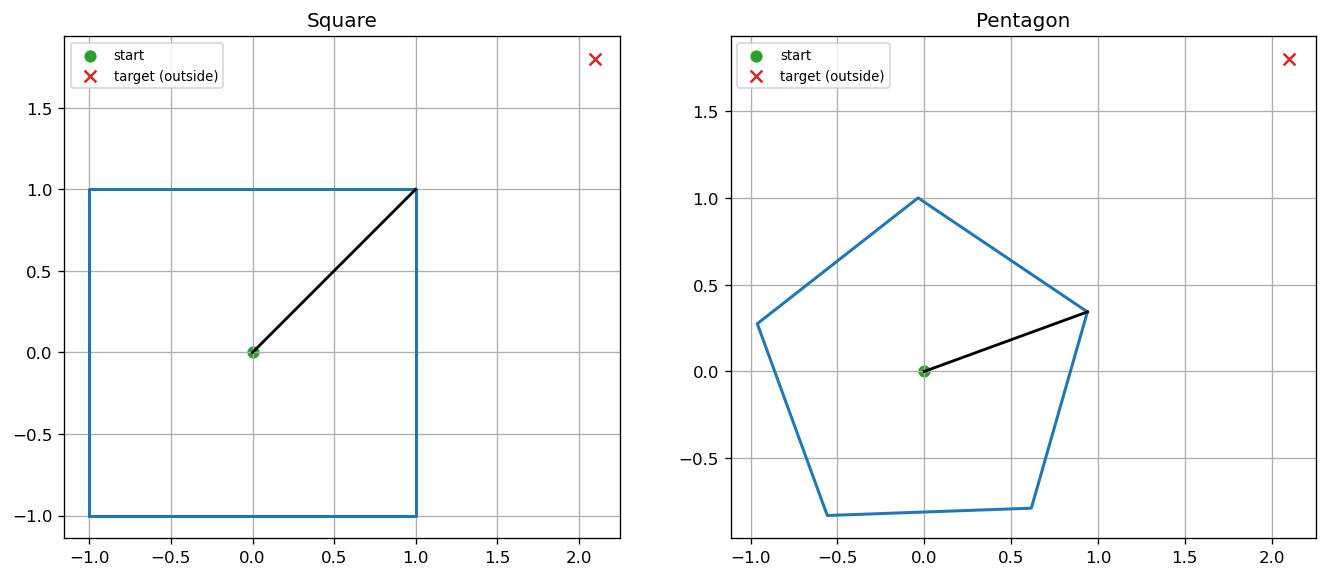

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.7), constrained_layout=True)
for ax, V, T, ttl in [(axes[0], sq, traj_sq, "Square"), (axes[1], pent, traj_pt, "Pentagon")]:
    P = np.vstack([V, V[0]])
    ax.plot(P[:,0], P[:,1], color="tab:blue", lw=1.8)
    ax.plot(T[:,0], T[:,1], color="k", lw=1.7)  # requested black path
    ax.scatter(T[0,0], T[0,1], color="tab:green", s=40, label="start")
    ax.scatter(target[0], target[1], color="tab:red", s=50, marker="x", label="target (outside)")
    ax.set_aspect("equal")
    ax.set_title(ttl)
    ax.legend(fontsize=8)
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
